In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
flights = pd.read_csv("C:/Users/Anastasia_Golubova/Yandex.Disk/OTUS_Networks/HW_graphs/2008.csv")

In [4]:
def make_datetime(df):

    df = df.copy()

    df["DepTime"] = df["DepTime"].fillna(0).astype(int)

    df["DepTime_str"] = df["DepTime"].astype(str).str.zfill(4)

    df["hour"] = df["DepTime_str"].str[:2].astype(int)
    df["minute"] = df["DepTime_str"].str[2:].astype(int)

    df["time"] = pd.to_datetime(
        dict(
            year=df["Year"],
            month=df["Month"],
            day=df["DayofMonth"],
            hour=df["hour"],
            minute=df["minute"]
        ),
        errors="coerce"
    )

    return df

In [5]:
flights = make_datetime(flights)

In [11]:
import random
from collections import defaultdict

### симуляция
def simulate_si_once(
    flights_df,
    start_node=0,
    p=0.3,
    origin_col="origin_id",
    dest_col="dest_id",
    time_col="time",
    id_to_name=None,
    seed=None
):

    if seed is not None:
        random.seed(seed)

    infected = {start_node}
    infection_times = defaultdict(list)


    start_name = id_to_name[start_node] if id_to_name is not None else start_node
    start_time = flights_df[time_col].iloc[0]
    infection_times[start_time].append(start_name)

    for row in flights_df.itertuples(index=False):
        origin = getattr(row, origin_col)
        dest = getattr(row, dest_col)
        t = getattr(row, time_col)

        # если рейс из заражённого аэропорта в ещё здоровый
        if origin in infected and dest not in infected:
            if random.random() < p:
                infected.add(dest)
                dest_name = id_to_name[dest] if id_to_name is not None else dest
                infection_times[t].append(dest_name)

    # если в момент времени заразился один аэропорт, оставляем строку,
    # если несколько, список
    result = {}
    for t in sorted(infection_times):
        result[t] = infection_times[t][0] if len(infection_times[t]) == 1 else infection_times[t]

    return result

In [12]:
infection_dict = simulate_si_once(
    flights_df=flights,
    start_node='ABE',          
    p=0.2,
    origin_col="Origin",
    dest_col="Dest",
    time_col="time",
    seed=42
)

print(infection_dict)

{Timestamp('2008-01-01 00:00:00'): ['CLD', 'OAK'], Timestamp('2008-01-01 06:46:00'): 'KTN', Timestamp('2008-01-01 08:10:00'): 'ASE', Timestamp('2008-01-01 08:11:00'): 'ROA', Timestamp('2008-01-01 08:15:00'): 'RDM', Timestamp('2008-01-01 08:16:00'): 'LGB', Timestamp('2008-01-01 08:20:00'): 'BZN', Timestamp('2008-01-01 09:01:00'): 'BIL', Timestamp('2008-01-01 09:40:00'): 'TEX', Timestamp('2008-01-01 09:52:00'): 'PIA', Timestamp('2008-01-01 10:05:00'): 'ILM', Timestamp('2008-01-01 10:06:00'): 'LNK', Timestamp('2008-01-01 10:11:00'): 'BMI', Timestamp('2008-01-01 10:18:00'): 'RFD', Timestamp('2008-01-01 10:40:00'): 'SEA', Timestamp('2008-01-01 10:56:00'): 'LAW', Timestamp('2008-01-01 11:00:00'): 'CIC', Timestamp('2008-01-01 11:12:00'): 'GUC', Timestamp('2008-01-01 11:17:00'): 'SUN', Timestamp('2008-01-01 11:21:00'): 'SBP', Timestamp('2008-01-01 11:37:00'): 'FCA', Timestamp('2008-01-01 12:45:00'): 'PDX', Timestamp('2008-01-01 12:57:00'): 'FAI', Timestamp('2008-01-01 12:58:00'): 'MBS', Timest

In [13]:
print(flights[["Origin", "Dest", "time"]].head())
print(flights["time"].dtype)

  Origin Dest                time
0    IAD  TPA 2008-01-03 20:03:00
1    IAD  TPA 2008-01-03 07:54:00
2    IND  BWI 2008-01-03 06:28:00
3    IND  BWI 2008-01-03 09:26:00
4    IND  BWI 2008-01-03 18:29:00
datetime64[ns]


In [16]:
## сделаем список всех зараженных по времени
def infection_dict_to_df(infection_dict):
    rows = []

    for t, airports in infection_dict.items():
        if isinstance(airports, list):
            for a in airports:
                rows.append((t, a))
        else:
            rows.append((t, airports))

    inf_df = pd.DataFrame(rows, columns=["time", "airport"])
    inf_df = inf_df.sort_values("time").reset_index(drop=True)
    return inf_df

In [17]:
inf_df = infection_dict_to_df(infection_dict)

In [18]:
inf_df

,time,airport
0,2008-01-01 00:00:00,CLD
1,2008-01-01 00:00:00,OAK
2,2008-01-01 06:46:00,KTN
3,2008-01-01 08:10:00,ASE
4,2008-01-01 08:11:00,ROA
...,...,...
298,2008-07-07 11:04:00,LMT
299,2008-07-07 20:21:00,OTH
300,2008-08-19 22:34:00,ITH
301,2008-10-06 10:30:00,HTS


In [19]:
### процент зараженных каждые 12 часов
def compute_infected_percentage_over_time(infection_dict, all_airports, start_time, end_time, step_hours=12):
    inf_df = infection_dict_to_df(infection_dict)

    total_airports = len(all_airports)

    time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")

    infected_counts = []
    infected_so_far = set()

    idx = 0
    times = inf_df["time"].tolist()
    airports = inf_df["airport"].tolist()

    for current_time in time_grid:
        while idx < len(times) and times[idx] <= current_time:
            infected_so_far.add(airports[idx])
            idx += 1

        infected_counts.append(len(infected_so_far) / total_airports * 100)

    return pd.DataFrame({
        "time": time_grid,
        "percent_infected": infected_counts
    })

In [21]:
### много симуляций для одного p
def run_multiple_simulations(
    flights_df,
    p,
    n_runs=10,
    start_node="ABE",
    origin_col="Origin",
    dest_col="Dest",
    time_col="time",
    step_hours=12
):
    all_airports = set(flights_df[origin_col]).union(set(flights_df[dest_col]))
    start_time = flights_df[time_col].min()
    end_time = flights_df[time_col].max()

    all_runs = []

    for run in range(n_runs):
        infection_dict = simulate_si_once(
            flights_df=flights_df,
            start_node=start_node,
            p=p,
            origin_col=origin_col,
            dest_col=dest_col,
            time_col=time_col,
            seed=42 + run
        )

        perc_df = compute_infected_percentage_over_time(
            infection_dict=infection_dict,
            all_airports=all_airports,
            start_time=start_time,
            end_time=end_time,
            step_hours=step_hours
        )

        perc_df["run"] = run
        perc_df["p"] = p
        all_runs.append(perc_df)

    return pd.concat(all_runs, ignore_index=True)

In [23]:
res_p_0_01 = run_multiple_simulations(
        flights_df=flights,
        p=0.01,
        n_runs=10,
        start_node="ABE",   
        origin_col="Origin",
        dest_col="Dest",
        time_col="time",
        step_hours=12
    )

C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start

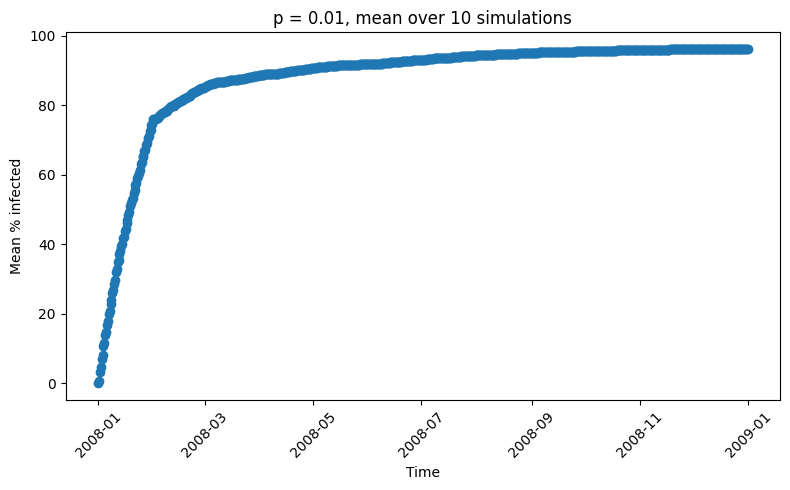

In [27]:
### рисуем график зависимости процента зараженных городов от времени (среднее по всем симулияциям)
mean_res = (
    res_p_0_01
    .groupby('time', as_index=False)['percent_infected']
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(mean_res['time'], mean_res['percent_infected'], marker='o')
plt.xlabel("Time")
plt.ylabel("Mean % infected")
plt.title("p = 0.01, mean over 10 simulations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
res_p_0_05 = run_multiple_simulations(
        flights_df=flights,
        p=0.05,
        n_runs=10,
        start_node="ABE",   
        origin_col="Origin",
        dest_col="Dest",
        time_col="time",
        step_hours=12
    )

C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start

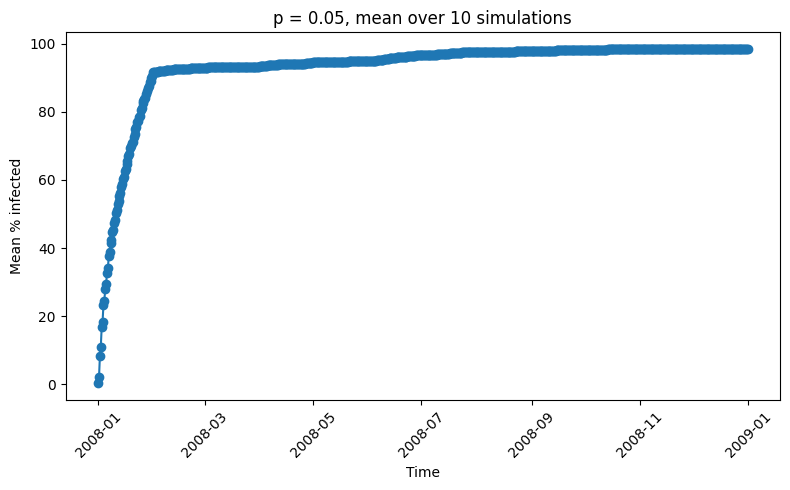

In [33]:
mean_res = (
    res_p_0_05
    .groupby('time', as_index=False)['percent_infected']
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(mean_res['time'], mean_res['percent_infected'], marker='o')
plt.xlabel("Time")
plt.ylabel("Mean % infected")
plt.title("p = 0.05, mean over 10 simulations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
res_p_0_1 = run_multiple_simulations(
        flights_df=flights,
        p=0.1,
        n_runs=10,
        start_node="ABE",   
        origin_col="Origin",
        dest_col="Dest",
        time_col="time",
        step_hours=12
    )

C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start

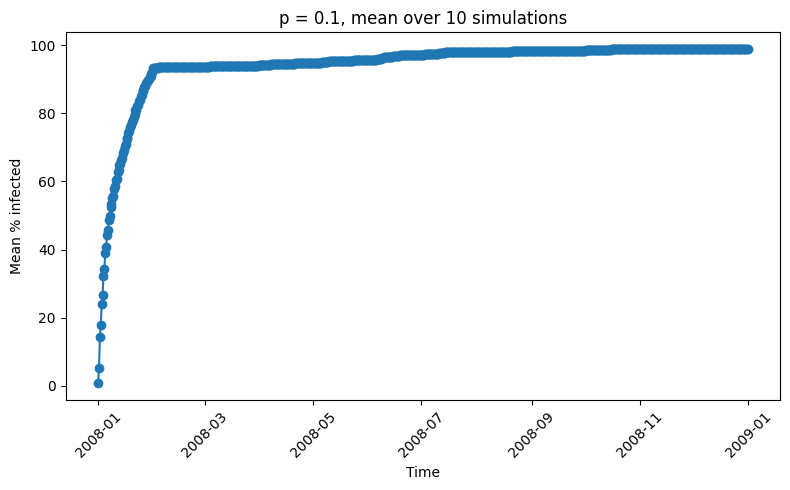

In [34]:
mean_res = (
    res_p_0_1
    .groupby('time', as_index=False)['percent_infected']
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(mean_res['time'], mean_res['percent_infected'], marker='o')
plt.xlabel("Time")
plt.ylabel("Mean % infected")
plt.title("p = 0.1, mean over 10 simulations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
res_p_0_5 = run_multiple_simulations(
        flights_df=flights,
        p=0.5,
        n_runs=10,
        start_node="ABE",   
        origin_col="Origin",
        dest_col="Dest",
        time_col="time",
        step_hours=12
    )

C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start

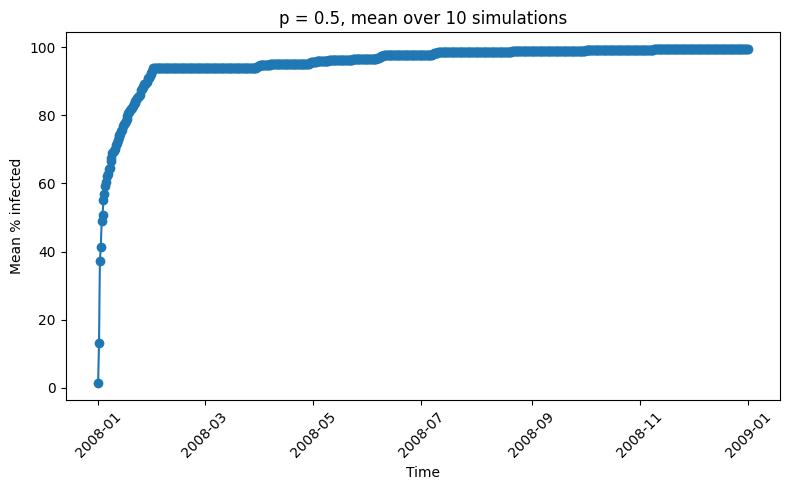

In [35]:
mean_res = (
    res_p_0_5
    .groupby('time', as_index=False)['percent_infected']
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(mean_res['time'], mean_res['percent_infected'], marker='o')
plt.xlabel("Time")
plt.ylabel("Mean % infected")
plt.title("p = 0.5, mean over 10 simulations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
res_p_1 = run_multiple_simulations(
        flights_df=flights,
        p=1,
        n_runs=10,
        start_node="ABE",   
        origin_col="Origin",
        dest_col="Dest",
        time_col="time",
        step_hours=12
    )

C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start_time, end=end_time, freq=f"{step_hours}H")
C:\Users\Anastasia_Golubova\AppData\Local\Temp\ipykernel_27168\1684331657.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_grid = pd.date_range(start=start

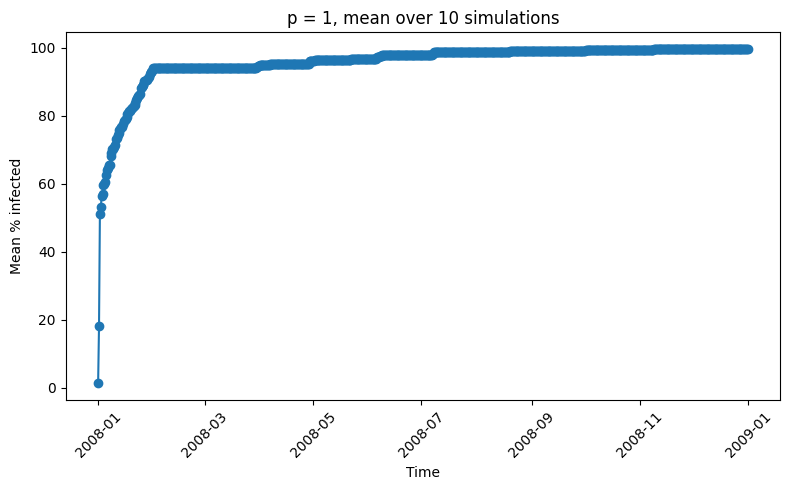

In [36]:
mean_res = (
    res_p_1
    .groupby('time', as_index=False)['percent_infected']
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(mean_res['time'], mean_res['percent_infected'], marker='o')
plt.xlabel("Time")
plt.ylabel("Mean % infected")
plt.title("p = 1, mean over 10 simulations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### видно, что чем больше вероятность распространения, тем более резкий скачок на графике, то есть инфекция распространяется быстрее

In [39]:
import networkx as nx

def build_airport_graph(flights_df, origin_col="Origin", dest_col="Dest"):
    df = flights_df[[origin_col, dest_col]].copy()

    df["a1"] = df[[origin_col, dest_col]].min(axis=1)
    df["a2"] = df[[origin_col, dest_col]].max(axis=1)

    edge_counts = (
        df.groupby(["a1", "a2"])
        .size()
        .reset_index(name="n_flights")
    )

    total_flights = len(df)
    edge_counts["weight"] = edge_counts["n_flights"] / total_flights

    G = nx.Graph()

    for row in edge_counts.itertuples(index=False):
        G.add_edge(row.a1, row.a2, weight=row.weight, n_flights=row.n_flights)

    return G, edge_counts

In [40]:
G, edge_table = build_airport_graph(flights)
print(G.number_of_nodes(), G.number_of_edges())
edge_table.head()

305 2834


,a1,a2,n_flights,weight
0,ABE,ATL,1705,2.432334e-04
1,ABE,BHM,1,1.426589e-07
2,ABE,CLE,1610,2.296808e-04
3,ABE,CLT,930,1.326728e-04
4,ABE,CVG,495,7.061615e-05


In [41]:
def simulate_si_once_times(
    flights_df,
    start_node="ABE",   
    p=0.5,
    origin_col="Origin",
    dest_col="Dest",
    time_col="time",
    seed=None
):
    if seed is not None:
        random.seed(seed)

    infected = {start_node}
    infection_time = {}

    start_time = flights_df[time_col].min()
    infection_time[start_node] = start_time

    for row in flights_df.itertuples(index=False):
        origin = getattr(row, origin_col)
        dest = getattr(row, dest_col)
        t = getattr(row, time_col)

        if origin in infected and dest not in infected:
            if random.random() < p:
                infected.add(dest)
                infection_time[dest] = t

    return infection_time

In [42]:
def run_si_simulations(
    flights_df,
    n_runs=50,
    start_node="ABE",
    p=0.5,
    origin_col="Origin",
    dest_col="Dest",
    time_col="time"
):
    all_runs = []

    for run in range(n_runs):
        inf_time = simulate_si_once_times(
            flights_df=flights_df,
            start_node=start_node,
            p=p,
            origin_col=origin_col,
            dest_col=dest_col,
            time_col=time_col,
            seed=42 + run
        )

        run_df = pd.DataFrame({
            "airport": list(inf_time.keys()),
            "infection_time": list(inf_time.values())
        })
        run_df["run"] = run
        all_runs.append(run_df)

    return pd.concat(all_runs, ignore_index=True)

In [43]:
sim_df = run_si_simulations(
    flights_df=flights,
    n_runs=50,
    start_node="ABE",
    p=0.5
)

sim_df.head()

,airport,infection_time,run
0,ABE,2008-01-01 00:00:00,0
1,CLE,2008-01-14 13:50:00,0
2,MSP,2008-01-03 07:25:00,0
3,DCA,2008-01-21 07:32:00,0
4,DFW,2008-01-17 16:42:00,0


In [44]:
### медианное время заражения
def compute_median_infection_time(sim_df):
    sim_df = sim_df.copy()

    start_times = sim_df.groupby("run")["infection_time"].min().rename("run_start")

    sim_df = sim_df.merge(start_times, on="run")
    sim_df["hours_to_infection"] = (
        (sim_df["infection_time"] - sim_df["run_start"]).dt.total_seconds() / 3600
    )

    median_df = (
        sim_df.groupby("airport", as_index=False)["hours_to_infection"]
        .median()
        .rename(columns={"hours_to_infection": "median_infection_hours"})
    )

    return median_df

In [45]:
median_inf_df = compute_median_infection_time(sim_df)
median_inf_df.head()

,airport,median_infection_hours
0,ABE,0.000000
1,ABI,40.216667
2,ABQ,165.100000
3,ABY,13.083333
4,ACK,3442.933333


In [46]:
### метрики графа
def compute_graph_metrics(G):
    clustering = nx.clustering(G, weight=None)
    degree = dict(G.degree())
    betweenness = nx.betweenness_centrality(G, weight=None)

    metrics_df = pd.DataFrame({
        "airport": list(G.nodes()),
        "clustering_coef": [clustering[n] for n in G.nodes()],
        "degree": [degree[n] for n in G.nodes()],
        "betweenness": [betweenness[n] for n in G.nodes()]
    })

    return metrics_df

In [47]:
metrics_df = compute_graph_metrics(G)
metrics_df.head()

,airport,clustering_coef,degree,betweenness
0,ABE,0.833333,12,0.000106
1,ATL,0.143232,173,0.201448
2,BHM,0.747899,35,0.000542
3,CLE,0.482807,76,0.004742
4,CLT,0.396443,84,0.015270


In [49]:
analysis_df = median_inf_df.merge(metrics_df, on="airport", how="inner")

In [50]:
def plot_scatter_vs_infection_time(df, x_col, y_col="median_infection_hours"):
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df, x=x_col, y=y_col)
    plt.xlabel(x_col)
    plt.ylabel("Median infection time (hours)")
    plt.title(f"Median infection time vs {x_col}")
    plt.tight_layout()
    plt.show()

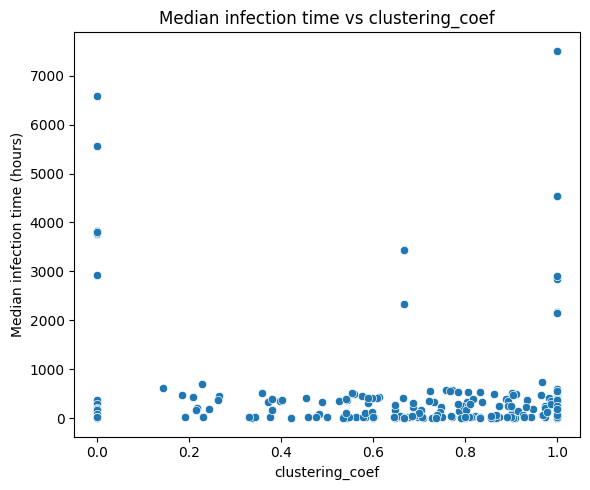

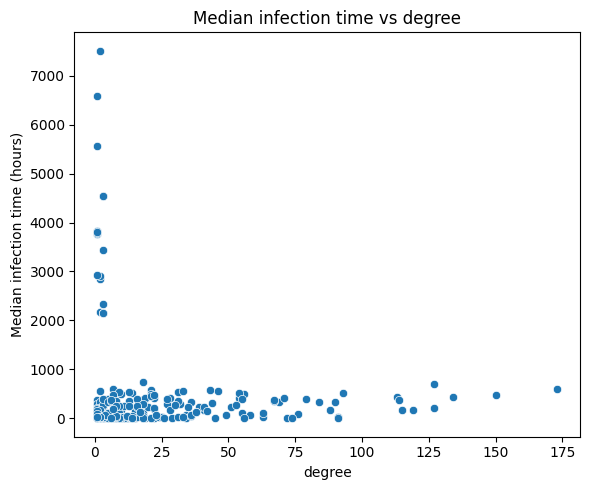

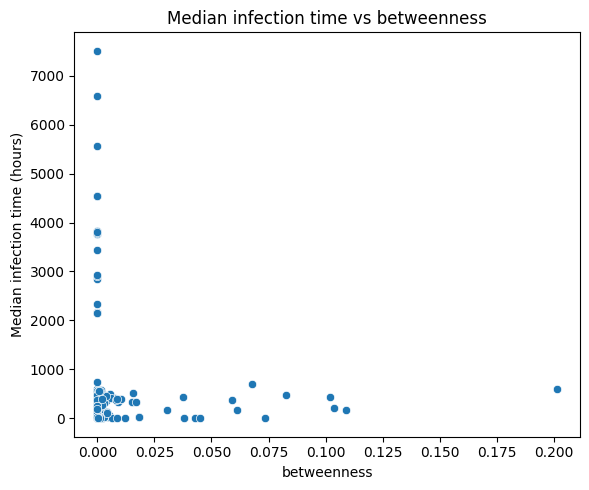

In [51]:
plot_scatter_vs_infection_time(analysis_df, "clustering_coef")
plot_scatter_vs_infection_time(analysis_df, "degree")
plot_scatter_vs_infection_time(analysis_df, "betweenness")

In [52]:
from scipy.stats import spearmanr

def spearman_with_infection_time(df, cols, y_col="median_infection_hours"):
    results = []

    for col in cols:
        rho, pval = spearmanr(df[col], df[y_col], nan_policy="omit")
        results.append({
            "metric": col,
            "spearman_rho": rho,
            "p_value": pval
        })

    return pd.DataFrame(results)

In [53]:
corr_df = spearman_with_infection_time(
    analysis_df,
    cols=["clustering_coef", "degree", "betweenness"]
)

corr_df

,metric,spearman_rho,p_value
0,clustering_coef,0.017291,0.763973
1,degree,0.211365,0.000206
2,betweenness,0.060162,0.295754


### Локальная кластеризация и центральность не влияют, корреляция незначима, есть положительная значимая корреляция между степенью и временем распространения. Логичнее была бы отрицательная корреляция (чем больше связей, тем быстрее заражение), однако аэропорты с большим числом связей могут находиться далеко от точки распространения и заражаться позже.